<a href="https://colab.research.google.com/github/rauttanushka69-lgtm/Python-Basic-Projects./blob/master/Task18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("ford.csv")

print(df.head(10))
print(df.tail())
print(df.shape)
print(df.dtypes)

     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    16700   Petrol  150  47.1  

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
154
(17812, 9)


In [ ]:
print(df.describe())
key_cols = ['price', 'mileage', 'year']
print(df[key_cols].agg(['min', 'max', 'mean', 'median']))

               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  
              price        mileage         year
min       495.00000       1.00000

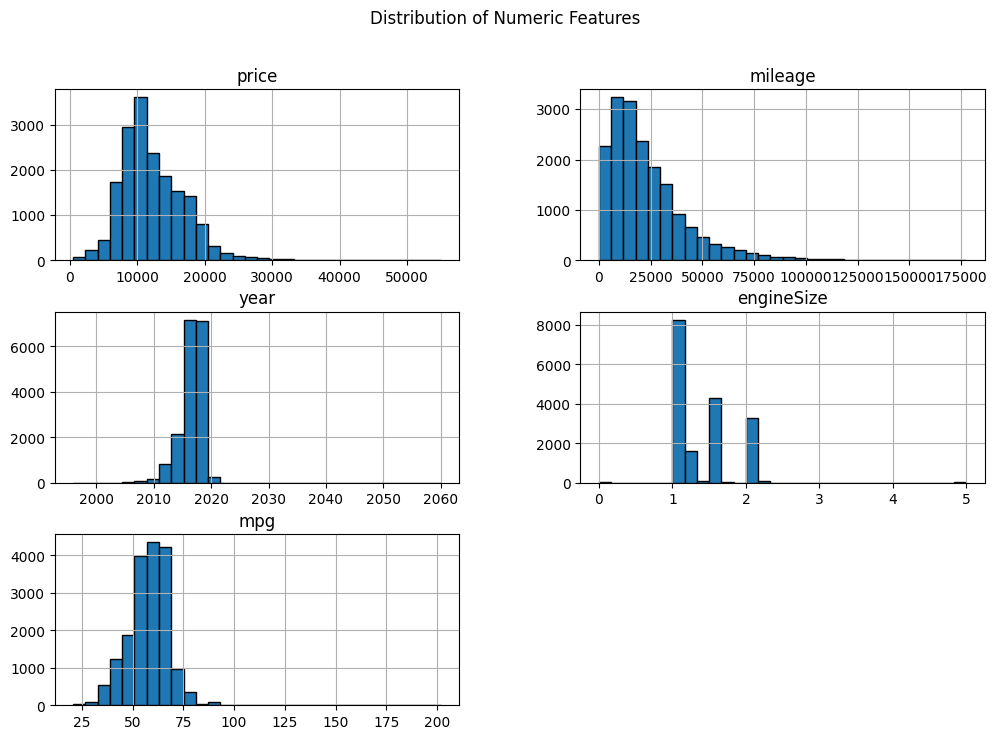

In [ ]:
numeric_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']
df[numeric_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numeric Features")
plt.show()

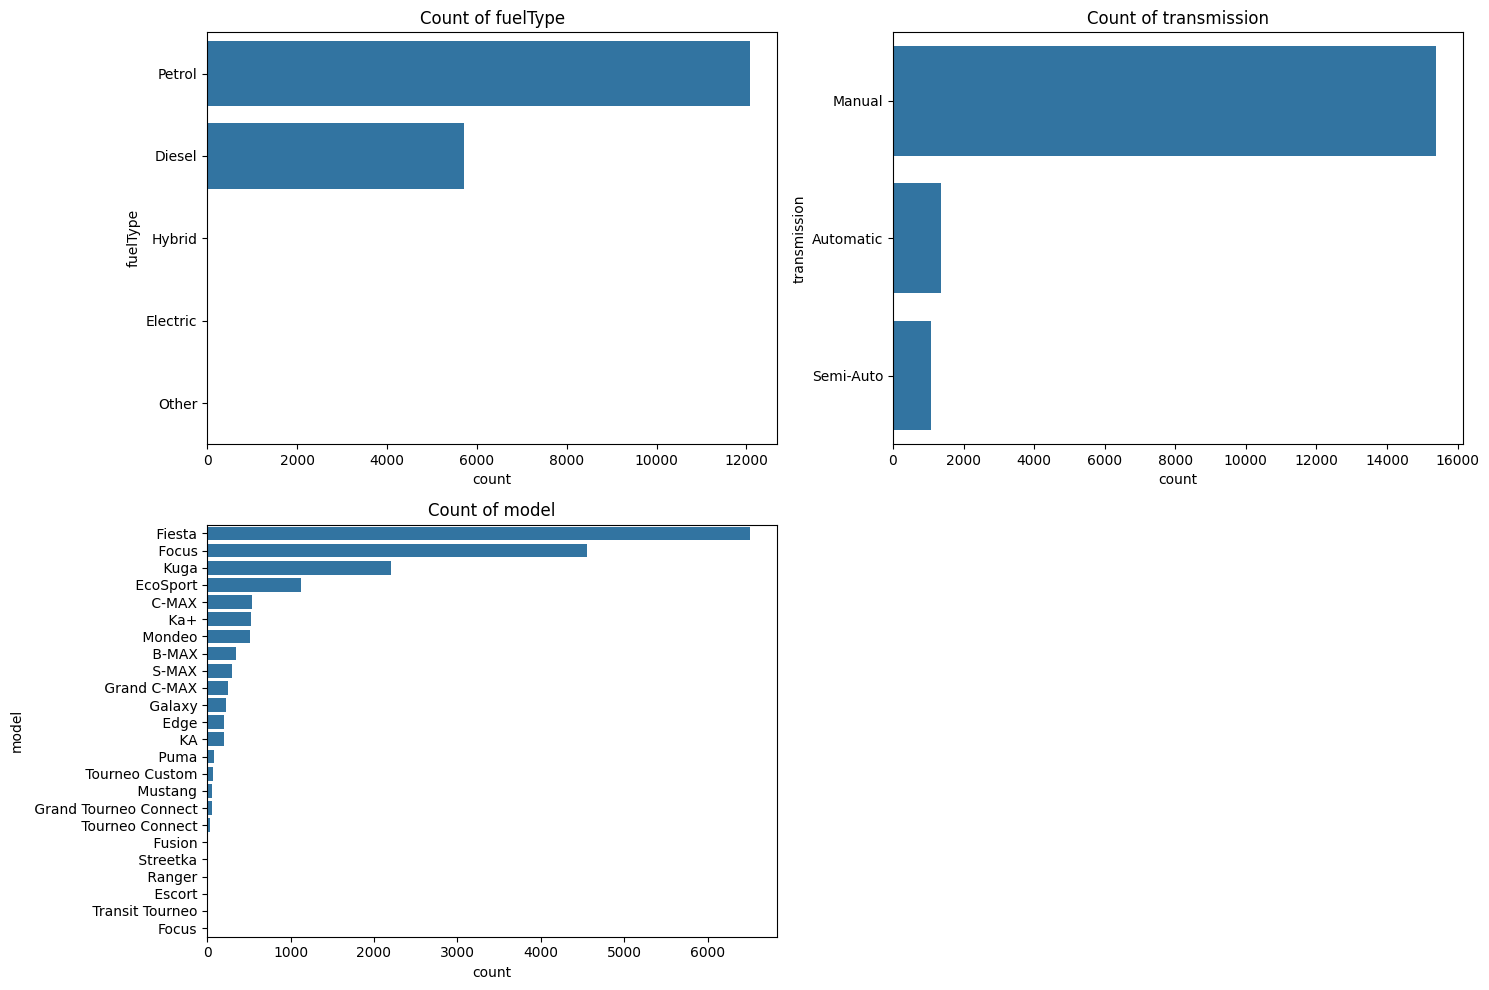

In [ ]:
cat_cols = ['fuelType', 'transmission', 'model']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()

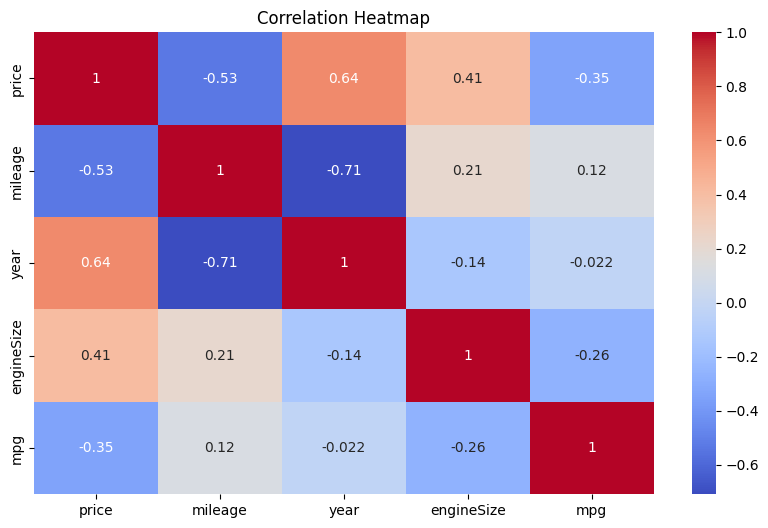

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ford.csv")
print(df.head())

     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0


In [ ]:
print(df.drop('price', axis=1).columns.tolist())
print('price')

['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
price


In [ ]:
# Q8
df_encoded = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
print(df_encoded.head())

# Used One-Hot Encoding to convert fuelType, transmission, model etc. to numbers
# ML models need only numeric data

Shape after encoding: (17966, 35)
   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...                   False   
2        False          False  ...                   False   
3        False          False  ...                   False   
4        False          False  ...                   False   

   model_ Tourneo Custom  model_ Transit Tourneo  model_Focus  \
0                  False                 

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Separate X and y
X = df.drop('price', axis=1)
y = df['price']

# 2. Select only numeric independent features
numeric_features = ['year', 'mileage', 'engineSize', 'mpg', 'tax']

# 3. Apply StandardScaler
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("First 5 rows of Scaled Data:")
print(X.head())

First 5 rows of Scaled Data:
     model      year transmission   mileage fuelType       tax       mpg  \
0   Fiesta  0.065128    Automatic -0.380998   Petrol  0.591358 -0.020442   
1    Focus  0.552866       Manual -0.733359   Petrol  0.591358 -0.020442   
2    Focus  0.065128       Manual -0.560132   Petrol  0.591358 -0.020442   
3   Fiesta  1.040605       Manual -0.662640   Petrol  0.510727 -1.738890   
4   Fiesta  1.040605    Automatic -1.123724   Petrol  0.510727 -0.909294   

   engineSize  
0   -0.811386  
1   -0.811386  
2   -0.811386  
3    0.345070  
4   -0.811386  


Missing Values:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
Shape after removing duplicates: (17812, 9)


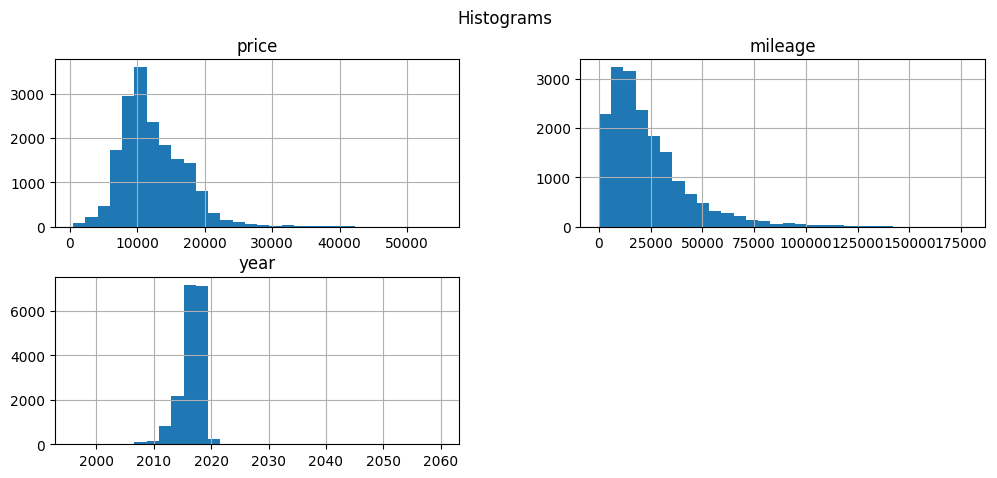

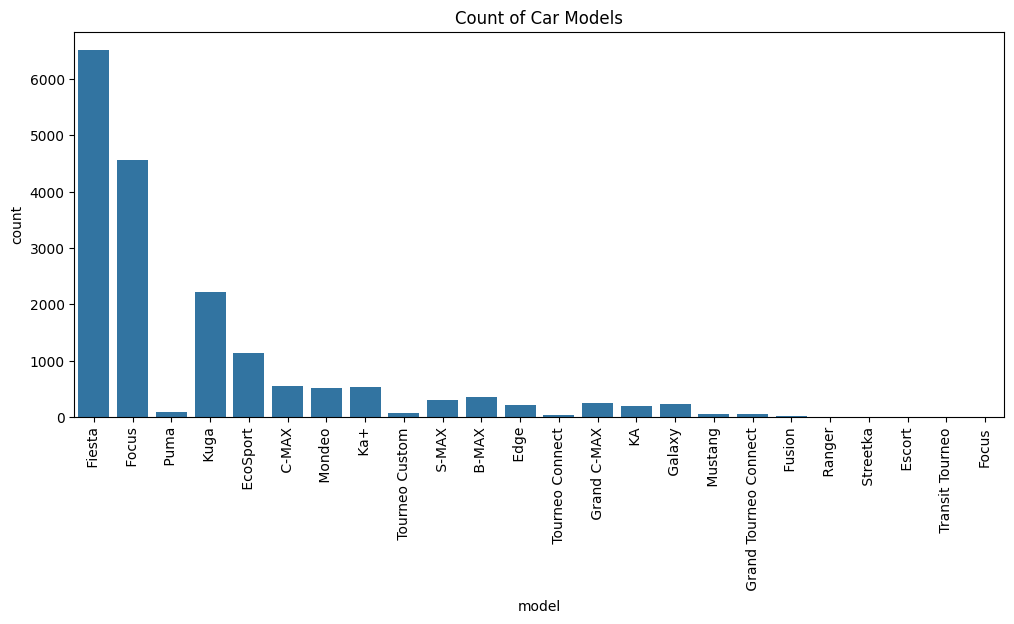

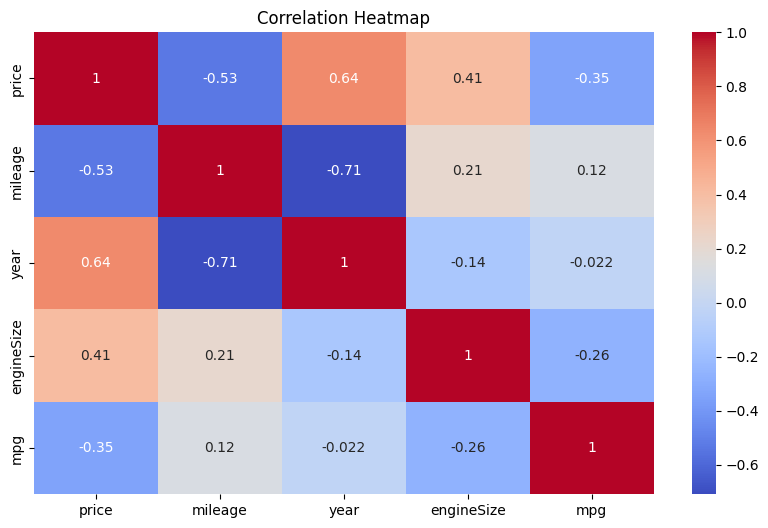

Input Features: ['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
Target Feature: price

Final Preprocessed Data Shape: (17812, 34)
       year   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0            False        False          False           True  ...   
1            False        False          False          False  ...   
2            False        False          False          False  ...   
3            False        False          False           True  ...   
4            False        False          False          

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Load and clean the data
df = pd.read_csv("ford.csv")
print("Missing Values:\n", df.isnull().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# 2. Perform EDA
# Histograms
df[['price', 'mileage', 'year']].hist(figsize=(12,5), bins=30)
plt.suptitle("Histograms")
plt.show()

# Countplots
plt.figure(figsize=(12,5))
sns.countplot(x='model', data=df)
plt.xticks(rotation=90)
plt.title("Count of Car Models")
plt.show()

# Heatmap
numeric_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 3. Identify input and output features
X = df.drop('price', axis=1)
y = df['price']
print("Input Features:", X.columns.tolist())
print("Target Feature: price")

# 4. Encode categorical variables
X = pd.get_dummies(X, columns=['model', 'fuelType', 'transmission'], drop_first=True)

# 5. Scale the numeric features
scaler = StandardScaler()
numeric_features = ['year', 'mileage', 'engineSize', 'mpg', 'tax']
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nFinal Preprocessed Data Shape:", X.shape)
print(X.head())